In [37]:
NAMENODE_PRIVATE_IP  = '192.168.5.39'
SPARK_MASTER_IP      = '192.168.5.39'
HDFS_PARQUET_PATH    = 'hdfs://192.168.5.39:9000/user/nordic/parquet'
SPARK_MASTER_URL     = f'spark://{SPARK_MASTER_IP}:7077'
EXECUTOR_MEMORY      = '2g'
EXECUTOR_CORES       = '1'
TOTAL_EXECUTOR_CORES = "1"
DRIVER_MEMORY        = '2g'
SHUFFLE_PARTITIONS   = '24'
NORDIC               = ['SE', 'DK', 'NO', 'FI', 'IS']
RUNTIMES             = {}
RUN_LABEL = "V2"
print(f'Path  : {HDFS_PARQUET_PATH}')
print(f'Master: {SPARK_MASTER_URL}')

Path  : hdfs://192.168.5.39:9000/user/nordic/parquet
Master: spark://192.168.5.39:7077


In [38]:
import time
from pyspark.sql import SparkSession, Window
from pyspark.sql.functions import (
    explode, col, floor, avg, count, collect_set,
    array_intersect, size, when, sum as spark_sum,
    lit, dense_rank, lag, round as spark_round,
    coalesce, percent_rank, ntile, stddev,
    max as spark_max, concat_ws, expr, countDistinct
)
print('Imports OK')

Imports OK


In [39]:
try:
    spark.stop()
except:
    pass

spark = (
    SparkSession.builder
    .appName('NordicAnalysis_v2')
    .master(SPARK_MASTER_URL)
    .config('spark.executor.memory',          EXECUTOR_MEMORY)
    .config('spark.executor.cores',           EXECUTOR_CORES)
    .config('spark.driver.memory',            DRIVER_MEMORY)
    .config('spark.sql.shuffle.partitions',   SHUFFLE_PARTITIONS)
    .config('spark.cores.max',                TOTAL_EXECUTOR_CORES)  # add this
    .config('spark.hadoop.fs.defaultFS',
            f'hdfs://{NAMENODE_PRIVATE_IP}:9000')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
print(f'Spark  : {spark.version}')
print(f'Master : {spark.sparkContext.master}')

Spark  : 3.5.1
Master : spark://192.168.5.39:7077


In [40]:
df = spark.read.parquet(HDFS_PARQUET_PATH)
print(f'Partitions : {df.rdd.getNumPartitions()}')
print(f'Columns    : {df.columns}')
t0 = time.time()
total = df.count()
RUNTIMES['count'] = round(time.time() - t0, 2)
print(f'Records    : {total:,}')
print(f'Count time : {RUNTIMES["count"]}s')
df.show(2, truncate=80)

Partitions : 24
Columns    : ['work_id', 'year', 'cited_by_count', 'authorships', 'topics']


Records    : 1,999,800
Count time : 2.45s


[Stage 4:>                                                          (0 + 1) / 1]

+--------------------------------+----+--------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                         work_id|year|cited_by_count|                                                                     authorships|                                                                          topics|
+--------------------------------+----+--------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|https://openalex.org/W2767813783|2017|          2439|[{[{[https://openalex.org/I4210102047, https://openalex.org/I149213910], Depa...|[{Trauma and Emergency Care Studies, {Health Sciences, https://openalex.org/d...|
|https://openalex.org/W3133517424|2021|          2438|[{[{[https://openalex.org/I4210117619], Drug Development, Novartis Pharmaceut.

In [41]:
def query1_institution_output(spark, path):
    df = spark.read.parquet(path)
    inst_df = (
        df.select('work_id', 'year', explode('authorships').alias('a'))
          .select('work_id', 'year', explode('a.institutions').alias('inst'))
          .select(
              'work_id',
              coalesce(col('year'),                 lit(0)).alias('year'),
              coalesce(col('inst.display_name'),    lit('Unknown')).alias('institution'),
              coalesce(col('inst.country_code'),    lit('')).alias('country_code')
          )
          .filter(col('country_code').isin(NORDIC))
          .filter(col('institution') != 'Unknown')
          .withColumn('decade', (floor(col('year') / 10) * 10).cast('int'))
    )
    decade_counts = (
        inst_df.groupBy('institution', 'country_code', 'decade')
               .agg(count('work_id').alias('paper_count'))
    )
    decade_window = Window.partitionBy('decade').orderBy(col('paper_count').desc())
    growth_window = Window.partitionBy('institution').orderBy('decade')
    return (
        decade_counts
        .withColumn('rank_in_decade',    dense_rank().over(decade_window))
        .withColumn('prev_decade_count', lag('paper_count', 1).over(growth_window))
        .withColumn('growth_pct',
            spark_round(
                (col('paper_count') - col('prev_decade_count')) /
                col('prev_decade_count') * 100, 1
            )
        )
        .withColumn('output_percentile', percent_rank().over(decade_window))
        .withColumn('output_tier',
            when(col('output_percentile') >= 0.9, 'Top 10%')
            .when(col('output_percentile') >= 0.5, 'Mid')
            .otherwise('Bottom 50%')
        )
        .orderBy('decade', 'rank_in_decade')
    )

t0 = time.time()
q1 = query1_institution_output(spark, HDFS_PARQUET_PATH)
q1.show(15, truncate=50)
RUNTIMES['Q1'] = round(time.time() - t0, 2)
print(f'Q1 runtime: {RUNTIMES["Q1"]}s')

[Stage 6:======================================================>  (23 + 1) / 24]

+---------------------------------+------------+------+-----------+--------------+-----------------+----------+---------------------+-----------+
|                      institution|country_code|decade|paper_count|rank_in_decade|prev_decade_count|growth_pct|    output_percentile|output_tier|
+---------------------------------+------------+------+-----------+--------------+-----------------+----------+---------------------+-----------+
|            Karolinska Institutet|          SE|  2000|      80866|             1|             NULL|      NULL|                  0.0| Bottom 50%|
|                  Lund University|          SE|  2000|      79318|             2|             NULL|      NULL|3.9231071008238524E-4| Bottom 50%|
|           University of Helsinki|          FI|  2000|      68153|             3|             NULL|      NULL| 7.846214201647705E-4| Bottom 50%|
|               Uppsala University|          SE|  2000|      57181|             4|             NULL|      NULL|0.00117693213

In [42]:
def query2_field_trends(spark, path):
    df = spark.read.parquet(path)
    nordic_works = (
        df.select('work_id', 'year', explode('authorships').alias('a'))
          .select('work_id', 'year', explode('a.institutions').alias('i'))
          .select(
              'work_id',
              coalesce(col('year'),           lit(0)).alias('year'),
              coalesce(col('i.country_code'), lit('')).alias('country_code')
          )
          .filter(col('country_code').isin(NORDIC))
          .withColumn('decade', (floor(col('year') / 10) * 10).cast('int'))
          .select('work_id', 'decade', 'country_code')
          .distinct()
    )
    topics = (
        df.select('work_id', explode('topics').alias('topic'))
          .select(
              'work_id',
              coalesce(col('topic.display_name'),        lit('Unknown')).alias('field'),
              coalesce(col('topic.field.display_name'),  lit('Unknown')).alias('broad_field')
          )
          .filter(col('field') != 'Unknown')
    )
    nordic_works.join(topics, 'work_id') \
                .createOrReplaceTempView('nordic_field_data')
    field_decade = spark.sql("""
        SELECT country_code, broad_field, field, decade,
               COUNT(DISTINCT work_id) AS paper_count
        FROM nordic_field_data
        GROUP BY country_code, broad_field, field, decade
        HAVING COUNT(DISTINCT work_id) >= 2
    """)
    trend_window = Window.partitionBy('country_code', 'field').orderBy('decade')
    return (
        field_decade
        .withColumn('prev_count',  lag('paper_count', 1).over(trend_window))
        .withColumn('growth_rate',
            spark_round(
                (col('paper_count') - col('prev_count')) /
                col('prev_count') * 100, 1
            )
        )
        .withColumn('prev_growth', lag('growth_rate', 1).over(trend_window))
        .withColumn('momentum',
            spark_round(col('growth_rate') - col('prev_growth'), 1)
        )
        .withColumn('trend_label',
            when(col('momentum') > 10,   'Accelerating')
            .when(col('momentum') < -10,  'Decelerating')
            .when(col('growth_rate') > 0, 'Growing')
            .when(col('growth_rate') < 0, 'Shrinking')
            .otherwise('Stable')
        )
        .orderBy('country_code', 'field', 'decade')
    )

t0 = time.time()
q2 = query2_field_trends(spark, HDFS_PARQUET_PATH)
q2.show(15, truncate=40)
RUNTIMES['Q2'] = round(time.time() - t0, 2)
print(f'Q2 runtime: {RUNTIMES["Q2"]}s')

[Stage 34:=============================>                            (1 + 1) / 2]

+------------+----------------------------------------+--------------------------------------+------+-----------+----------+-----------+-----------+--------+------------+
|country_code|                             broad_field|                                 field|decade|paper_count|prev_count|growth_rate|prev_growth|momentum| trend_label|
+------------+----------------------------------------+--------------------------------------+------+-----------+----------+-----------+-----------+--------+------------+
|          DK|Biochemistry, Genetics and Molecular ...|           14-3-3 protein interactions|  2000|         37|      NULL|       NULL|       NULL|    NULL|      Stable|
|          DK|Biochemistry, Genetics and Molecular ...|           14-3-3 protein interactions|  2010|         40|        37|        8.1|       NULL|    NULL|     Growing|
|          DK|Biochemistry, Genetics and Molecular ...|           14-3-3 protein interactions|  2020|         12|        40|      -70.0|        8

In [43]:
def query3_citation_impact(spark, path):
    df = spark.read.parquet(path)
    base = (
        df.select('work_id', 'cited_by_count', 'year',
                  explode('authorships').alias('a'))
          .select('work_id',
                  coalesce(col('cited_by_count'), lit(0)).alias('citations'),
                  coalesce(col('year'),           lit(0)).alias('year'),
                  explode('a.institutions').alias('inst'))
          .select('work_id', 'citations', 'year',
                  coalesce(col('inst.display_name'), lit('Unknown')).alias('institution'),
                  coalesce(col('inst.country_code'), lit('')).alias('country_code'))
          .filter(col('country_code').isin(NORDIC))
          .filter(col('institution') != 'Unknown')
    )
    inst_stats = (
        base.groupBy('institution', 'country_code')
            .agg(
                count('work_id').alias('paper_count'),
                spark_round(avg('citations'),    2).alias('avg_citations'),
                spark_round(stddev('citations'), 2).alias('stddev_citations'),
                spark_max('citations').alias('max_citations'),
                spark_sum(when(col('citations') == 0, 1).otherwise(0))
                    .alias('zero_citation_papers')
            )
            .filter(col('paper_count') >= 5)
    )
    country_window  = Window.partitionBy('country_code')
    quartile_window = Window.orderBy('avg_citations')
    return (
        inst_stats
        .withColumn('country_avg',
            spark_round(avg('avg_citations').over(country_window), 2))
        .withColumn('vs_country_avg',
            spark_round(col('avg_citations') - col('country_avg'), 2))
        .withColumn('is_outlier',
            col('avg_citations') > col('country_avg') * 2)
        .withColumn('citation_quartile', ntile(4).over(quartile_window))
        .withColumn('quartile_label',
            when(col('citation_quartile') == 4, 'Top 25%')
            .when(col('citation_quartile') == 3, 'Upper Mid')
            .when(col('citation_quartile') == 2, 'Lower Mid')
            .otherwise('Bottom 25%')
        )
        .orderBy(col('avg_citations').desc())
    )

t0 = time.time()
q3 = query3_citation_impact(spark, HDFS_PARQUET_PATH)
q3.show(15, truncate=45)
RUNTIMES['Q3'] = round(time.time() - t0, 2)
print(f'Q3 runtime: {RUNTIMES["Q3"]}s')

26/03/20 16:03:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/20 16:03:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/20 16:03:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/20 16:03:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/20 16:03:55 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/20 16:03:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/03/20 1

+---------------------------------------------+------------+-----------+-------------+----------------+-------------+--------------------+-----------+--------------+----------+-----------------+--------------+
|                                  institution|country_code|paper_count|avg_citations|stddev_citations|max_citations|zero_citation_papers|country_avg|vs_country_avg|is_outlier|citation_quartile|quartile_label|
+---------------------------------------------+------------+-----------+-------------+----------------+-------------+--------------------+-----------+--------------+----------+-----------------+--------------+
|                            Metallco (Norway)|          NO|         43|      1165.28|          181.78|         1193|                   0|      32.09|       1133.19|      true|                4|       Top 25%|
|                         Uson Marine (Sweden)|          SE|         11|       723.91|           239.1|          796|                   0|       38.1|        68

In [44]:
def query4_international_collab(spark, path, shuffle_partitions=None):
    if shuffle_partitions:
        spark.conf.set('spark.sql.shuffle.partitions', str(shuffle_partitions))
    df = spark.read.parquet(path)
    paper_countries = (
        df.select('work_id', 'year', explode('authorships').alias('a'))
          .select('work_id',
                  coalesce(col('year'), lit(0)).alias('year'),
                  explode('a.institutions').alias('inst'))
          .select('work_id', 'year',
                  coalesce(col('inst.country_code'), lit('')).alias('cc'))
          .filter(col('cc') != '')
          .repartition(col('work_id'))
          .groupBy('work_id', 'year')
          .agg(collect_set('cc').alias('all_countries'))
    )
    nordic_lit       = lit(NORDIC)
    nordic_array_str = ', '.join([f"'{c}'" for c in NORDIC])
    flagged = (
        paper_countries
        .withColumn('decade', (floor(col('year') / 10) * 10).cast('int'))
        .withColumn('nordic_countries',
            array_intersect(col('all_countries'), nordic_lit))
        .withColumn('has_nordic', size(col('nordic_countries')) > 0)
        .withColumn('intl_countries',
            expr(f'filter(all_countries,'
                 f' x -> not array_contains(array({nordic_array_str}), x))'))
        .withColumn('is_international',
            col('has_nordic') & (size(col('intl_countries')) > 0))
        .withColumn('collaboration_intensity',
            size(col('intl_countries')).cast('double'))
        .filter(col('has_nordic'))
    )
    per_country = (
        flagged
        .select('work_id', 'decade', 'is_international',
                'collaboration_intensity',
                explode('nordic_countries').alias('nordic_country'))
        .filter(col('nordic_country').isin(NORDIC))
    )
    agg = (
        per_country
        .groupBy('nordic_country', 'decade')
        .agg(
            count('work_id').alias('total_papers'),
            spark_sum(when(col('is_international'), 1).otherwise(0))
                .alias('international_papers'),
            spark_round(
                avg(when(col('is_international'),
                    col('collaboration_intensity'))), 2
            ).alias('avg_intl_countries_when_collab')
        )
        .withColumn('collab_rate',
            spark_round(col('international_papers') / col('total_papers'), 4))
    )
    trend_window = Window.partitionBy('nordic_country').orderBy('decade')
    return (
        agg
        .withColumn('prev_rate',   lag('collab_rate', 1).over(trend_window))
        .withColumn('rate_change',
            spark_round(col('collab_rate') - col('prev_rate'), 4))
        .withColumn('trend',
            when(col('rate_change') > 0.02,   'Increasing')
            .when(col('rate_change') < -0.02,  'Decreasing')
            .when(col('prev_rate').isNull(),   'Baseline')
            .otherwise('Stable')
        )
        .orderBy('nordic_country', 'decade')
    )

t0 = time.time()
q4 = query4_international_collab(spark, HDFS_PARQUET_PATH)
q4.show(20)
RUNTIMES['Q4'] = round(time.time() - t0, 2)
print(f'Q4 runtime: {RUNTIMES["Q4"]}s')

[Stage 55:======================================>                   (2 + 1) / 3]

+--------------+------+------------+--------------------+------------------------------+-----------+---------+-----------+----------+
|nordic_country|decade|total_papers|international_papers|avg_intl_countries_when_collab|collab_rate|prev_rate|rate_change|     trend|
+--------------+------+------------+--------------------+------------------------------+-----------+---------+-----------+----------+
|            DK|  2000|      111841|               47122|                          1.76|     0.4213|     NULL|       NULL|  Baseline|
|            DK|  2010|      266252|              137944|                          2.36|     0.5181|   0.4213|     0.0968|Increasing|
|            DK|  2020|      138383|               86169|                          2.77|     0.6227|   0.5181|     0.1046|Increasing|
|            FI|  2000|      106266|               40668|                          1.76|     0.3827|     NULL|       NULL|  Baseline|
|            FI|  2010|      195028|               99338|     

In [45]:
def query5_cross_nordic(spark, path):
    df = spark.read.parquet(path)
    nordic_papers = (
        df.select('work_id', 'year', explode('authorships').alias('a'))
          .select('work_id',
                  coalesce(col('year'), lit(0)).alias('year'),
                  explode('a.institutions').alias('inst'))
          .select(
              'work_id',
              (floor(col('year') / 10) * 10).cast('int').alias('decade'),
              coalesce(col('inst.country_code'),  lit('')).alias('country'),
              coalesce(col('inst.display_name'),  lit('Unknown')).alias('institution')
          )
          .filter(col('country').isin(NORDIC))
          .distinct()
    )
    left  = nordic_papers.alias('a')
    right = nordic_papers.alias('b')
    pairs = (
        left.join(right, on=['work_id', 'decade'])
        .filter(col('a.country') < col('b.country'))
        .select(
            'work_id', 'decade',
            col('a.country').alias('country_a'),
            col('b.country').alias('country_b'),
            col('a.institution').alias('inst_a'),
            col('b.institution').alias('inst_b')
        )
    )
    country_pair_decade = (
        pairs
        .groupBy('country_a', 'country_b', 'decade')
        .agg(
            count('work_id').alias('co_authored_papers'),
            countDistinct('inst_a').alias('unique_inst_a'),
            countDistinct('inst_b').alias('unique_inst_b')
        )
    )
    pair_window = Window.partitionBy('country_a', 'country_b')
    return (
        country_pair_decade
        .withColumn('total_pair_papers',
            spark_sum('co_authored_papers').over(pair_window))
        .withColumn('decade_share',
            spark_round(col('co_authored_papers') / col('total_pair_papers'), 3))
        .withColumn('pair_label',
            concat_ws('-', col('country_a'), col('country_b')))
        .orderBy(col('total_pair_papers').desc(), 'decade')
    )

t0 = time.time()
q5 = query5_cross_nordic(spark, HDFS_PARQUET_PATH)
q5.show(20)
RUNTIMES['Q5'] = round(time.time() - t0, 2)
print(f'Q5 runtime: {RUNTIMES["Q5"]}s')

[Stage 69:===========================================>              (3 + 1) / 4]

+---------+---------+------+------------------+-------------+-------------+-----------------+------------+----------+
|country_a|country_b|decade|co_authored_papers|unique_inst_a|unique_inst_b|total_pair_papers|decade_share|pair_label|
+---------+---------+------+------------------+-------------+-------------+-----------------+------------+----------+
|       DK|       SE|  2000|             14763|          219|          289|           121332|       0.122|     DK-SE|
|       DK|       SE|  2010|             60563|          324|          463|           121332|       0.499|     DK-SE|
|       DK|       SE|  2020|             46006|          286|          394|           121332|       0.379|     DK-SE|
|       FI|       SE|  2000|             14949|          217|          277|           112158|       0.133|     FI-SE|
|       FI|       SE|  2010|             56279|          286|          414|           112158|       0.502|     FI-SE|
|       FI|       SE|  2020|             40930|         

=== Query Runtimes (Unpartitioned Parquet) ===
  count   : 2.45s
  Q1      : 17.64s
  Q2      : 65.69s
  Q3      : 13.85s
  Q4      : 64.18s
  Q5      : 58.46s


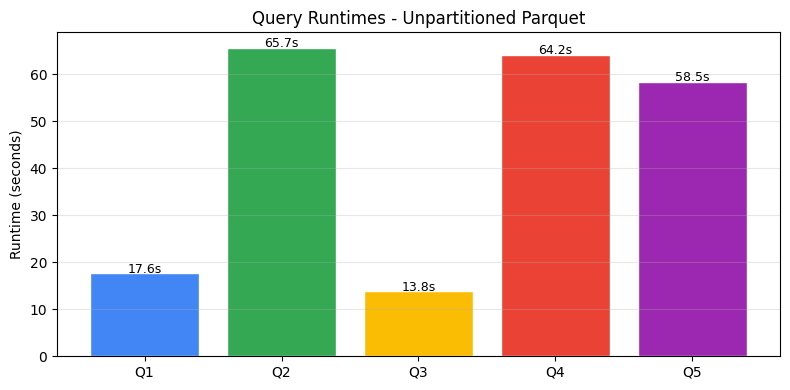

Saved: query_runtimes_parquet.png


In [46]:
import matplotlib.pyplot as plt

print('=== Query Runtimes (Unpartitioned Parquet) ===')
for k, v in RUNTIMES.items():
    print(f'  {k:<8}: {v}s')

queries = [k for k in RUNTIMES if k != 'count']
times   = [RUNTIMES[k] for k in queries]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(queries, times,
              color=['#4285f4', '#34a853', '#fbbc04', '#ea4335', '#9c27b0'],
              edgecolor='white')
ax.set_ylabel('Runtime (seconds)')
ax.set_title('Query Runtimes - Unpartitioned Parquet')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{t:.1f}s', ha='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{RUN_LABEL}query_runtimes_parquet.png', dpi=150)
plt.show()
print('Saved: query_runtimes_parquet.png')

In [47]:
spark.stop()
print('SparkSession stopped.')

SparkSession stopped.


Saved results for run V2 to benchmark_results.csv


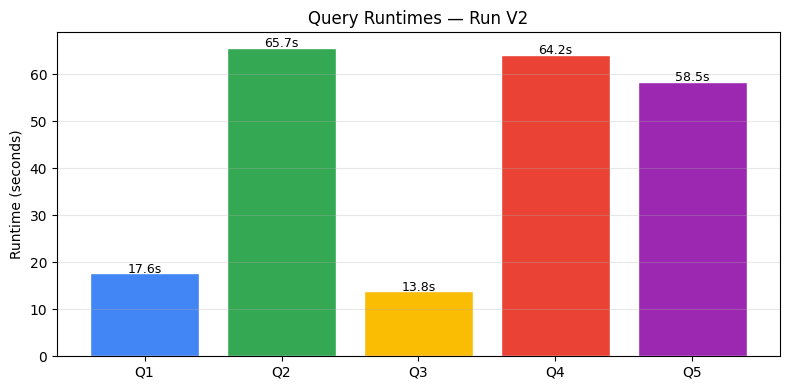

Saved: query_runtimes_V2.png


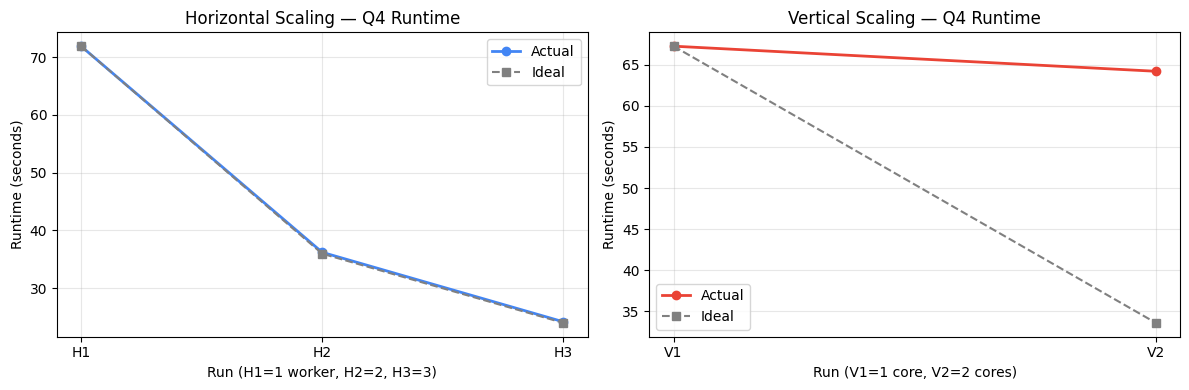

Saved: scaling_comparison.png


In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# ============================================================
# BENCHMARK DATA COLLECTION + PLOTTING
# Call this after each run with the run label e.g. "H1", "H2", "H3", "V1", "V2"
# ============================================================

   # <-- CHANGE THIS before each run: H1, H2, H3, V1, V2

# Save runtimes to CSV
csv_file = "benchmark_results.csv"
rows = []
for query, runtime in RUNTIMES.items():
    rows.append({
        "run":     RUN_LABEL,
        "query":   query,
        "runtime": runtime
    })

df_results = pd.DataFrame(rows)

# Append to CSV (create if not exists)
if os.path.exists(csv_file):
    df_results.to_csv(csv_file, mode='a', header=False, index=False)
else:
    df_results.to_csv(csv_file, mode='w', header=True, index=False)

print(f"Saved results for run {RUN_LABEL} to {csv_file}")

# Plot runtimes for this run
queries = [k for k in RUNTIMES if k != 'count']
times   = [RUNTIMES[k] for k in queries]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(queries, times,
              color=['#4285f4', '#34a853', '#fbbc04', '#ea4335', '#9c27b0'],
              edgecolor='white')
ax.set_ylabel('Runtime (seconds)')
ax.set_title(f'Query Runtimes — Run {RUN_LABEL}')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{t:.1f}s', ha='center', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plot_file = f"query_runtimes_{RUN_LABEL}.png"
plt.savefig(plot_file, dpi=150)
plt.show()
print(f"Saved: {plot_file}")

# After all runs done — plot scaling comparison
# Only runs if we have H1, H2, H3 data
df_all = pd.read_csv(csv_file)
h_runs = [r for r in df_all['run'].unique() if r.startswith('H')]
v_runs = [r for r in df_all['run'].unique() if r.startswith('V')]

if len(h_runs) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Horizontal scaling — Q4 runtime vs workers
    q4_h = df_all[(df_all['query'] == 'Q4') & (df_all['run'].isin(h_runs))]
    q4_h = q4_h.sort_values('run')
    axes[0].plot(q4_h['run'], q4_h['runtime'], marker='o', color='#4285f4', linewidth=2, label='Actual')
    if len(q4_h) > 0:
        baseline = q4_h['runtime'].iloc[0]
        ideal = [baseline / (i+1) for i in range(len(q4_h))]
        axes[0].plot(q4_h['run'], ideal, marker='s', linestyle='--', color='gray', label='Ideal')
    axes[0].set_title('Horizontal Scaling — Q4 Runtime')
    axes[0].set_ylabel('Runtime (seconds)')
    axes[0].set_xlabel('Run (H1=1 worker, H2=2, H3=3)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Vertical scaling — Q4 runtime vs cores
    if len(v_runs) >= 1:
        q4_v = df_all[(df_all['query'] == 'Q4') & (df_all['run'].isin(v_runs))]
        q4_v = q4_v.sort_values('run')
        axes[1].plot(q4_v['run'], q4_v['runtime'], marker='o', color='#ea4335', linewidth=2, label='Actual')
        if len(q4_v) > 0:
            baseline_v = q4_v['runtime'].iloc[0]
            ideal_v = [baseline_v / (i+1) for i in range(len(q4_v))]
            axes[1].plot(q4_v['run'], ideal_v, marker='s', linestyle='--', color='gray', label='Ideal')
        axes[1].set_title('Vertical Scaling — Q4 Runtime')
        axes[1].set_ylabel('Runtime (seconds)')
        axes[1].set_xlabel('Run (V1=1 core, V2=2 cores)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('scaling_comparison.png', dpi=150)
    plt.show()
    print("Saved: scaling_comparison.png")